# Entrenamiento y comparación de modelos — Heart Disease Dataset

Proyecto académico: detección temprana de enfermedades cardiovasculares mediante clasificación binaria.

> Este notebook compara modelos interpretables y modelos más complejos usando el dataset preprocesado `heart_disease_processed.csv`.

## 1. Preparación inicial

Métricas utilizadas:

- **Accuracy**: proporción total de predicciones correctas.
- **Precision**: proporción de predicciones positivas que realmente son positivas.
- **Recall**: proporción de pacientes enfermos correctamente detectados. En medicina suele ser crítica porque reduce falsos negativos.
- **F1-score**: media armónica entre Precision y Recall.
- **ROC-AUC**: capacidad global del modelo para separar clases en distintos umbrales de decisión.

In [1]:
import os
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATASET_PATH = "heart_disease_processed.csv"

### Carga del dataset procesado

El archivo debe provenir del notebook de preprocesamiento. La columna `num` no debe estar presente, porque codifica el diagnóstico original y causaría *data leakage*.

In [2]:
if not os.path.exists(DATASET_PATH):
    raise FileNotFoundError(
        "No se encontró heart_disease_processed.csv. "
        "Ejecuta primero el notebook 02_Preprocessing_Heart_Disease.ipynb "
        "o sube el archivo al entorno de Colab."
    )

df = pd.read_csv(DATASET_PATH)

if "num" in df.columns:
    raise ValueError("La columna `num` no debe estar en el dataset modelado por riesgo de data leakage.")

X = df.drop(columns=["target"])
y = df["target"]

display(df.head())
print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

,age,trestbps,chol,thalach,oldpeak,ca,sex_0,sex_1,cp_1,cp_2,cp_3,cp_4,fbs_0,fbs_1,restecg_0,restecg_1,restecg_2,exang_0,exang_1,slope_1,slope_2,slope_3,thal_3.0,thal_6.0,thal_7.0,target
0,0.948726,0.757525,-0.264900,0.017197,1.087338,-0.711131,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,1,0,0
1,1.392002,1.611220,0.760415,-1.821905,0.397182,2.504881,0,1,0,0,0,1,1,0,0,0,1,0,1,0,1,0,1,0,0,1
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,1.432877,0,1,0,0,0,1,1,0,0,0,1,0,1,0,1,0,0,0,1,1
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,-0.711131,0,1,0,0,1,0,1,0,1,0,0,1,0,0,0,1,1,0,0,0
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,-0.711131,1,0,0,1,0,0,1,0,0,0,1,1,0,1,0,0,1,0,0,0


Forma de X: (303, 25)
Forma de y: (303,)


## 2. División del dataset

Se usa división estratificada para conservar la prevalencia de enfermedad en entrenamiento y prueba.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Tamaño de train:", X_train.shape[0])
print("Tamaño de test:", X_test.shape[0])

class_distribution = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).sort_index(),
    "test": y_test.value_counts(normalize=True).sort_index(),
}).rename(index={0: "Ausencia de enfermedad", 1: "Presencia de enfermedad"})

class_distribution

Tamaño de train: 242
Tamaño de test: 61


,train,test
target,,
Ausencia de enfermedad,0.541322,0.540984
Presencia de enfermedad,0.458678,0.459016


## 3. Definición de modelos

Se comparan modelos interpretables, modelos de ensamble y una red neuronal multicapa. Todos usan `random_state=42` cuando el algoritmo lo permite.

In [4]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "Neural Network": MLPClassifier(max_iter=1000, random_state=RANDOM_STATE),
}

models

{'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
 'Decision Tree': DecisionTreeClassifier(random_state=42),
 'SVM': SVC(probability=True, random_state=42),
 'Random Forest': RandomForestClassifier(random_state=42),
 'Gradient Boosting': GradientBoostingClassifier(random_state=42),
 'Neural Network': MLPClassifier(max_iter=1000, random_state=42)}

## 4. Entrenamiento y evaluación

In [5]:
def obtener_puntajes_positivos(model, features):
    """Obtiene puntajes continuos para calcular ROC-AUC.

    Parámetros
    ----------
    model : estimator
        Modelo de clasificación entrenado.
    features : pd.DataFrame
        Matriz de características donde se calcularán los puntajes.

    Retorna
    -------
    np.ndarray
        Probabilidades o puntajes asociados a la clase positiva.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(features)[:, 1]
    return model.decision_function(features)


def evaluate_model(model, X_train, X_test, y_train, y_test):
    """Entrena y evalúa un modelo de clasificación binaria.

    Parámetros
    ----------
    model : estimator
        Modelo compatible con la interfaz de scikit-learn.
    X_train : pd.DataFrame
        Variables predictoras de entrenamiento.
    X_test : pd.DataFrame
        Variables predictoras de prueba.
    y_train : pd.Series
        Variable objetivo de entrenamiento.
    y_test : pd.Series
        Variable objetivo de prueba.

    Retorna
    -------
    dict
        Métricas principales para comparación de modelos.
    """
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_score = obtener_puntajes_positivos(model, X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_score),
    }

In [6]:
results = []
trained_models = {}

for model_name, model in models.items():
    metrics = evaluate_model(model, X_train, X_test, y_train, y_test)
    results.append({"Model": model_name, **metrics})
    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM,0.901639,0.866667,0.928571,0.896552,0.958874
1,Logistic Regression,0.868852,0.812500,0.928571,0.866667,0.957792
2,Gradient Boosting,0.885246,0.838710,0.928571,0.881356,0.943723
3,Neural Network,0.868852,0.812500,0.928571,0.866667,0.942641
4,Random Forest,0.868852,0.833333,0.892857,0.862069,0.935065
5,Decision Tree,0.754098,0.685714,0.857143,0.761905,0.761905


## 5. Tabla comparativa

La tabla `results_df` se ordena por ROC-AUC, porque esta métrica resume la capacidad discriminativa del modelo en clasificación binaria.

In [7]:
results_df.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1-score": "{:.3f}",
    "ROC-AUC": "{:.3f}",
})

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,SVM,0.902,0.867,0.929,0.897,0.959
1,Logistic Regression,0.869,0.812,0.929,0.867,0.958
2,Gradient Boosting,0.885,0.839,0.929,0.881,0.944
3,Neural Network,0.869,0.812,0.929,0.867,0.943
4,Random Forest,0.869,0.833,0.893,0.862,0.935
5,Decision Tree,0.754,0.686,0.857,0.762,0.762


## 6. Validación cruzada estratificada

La validación cruzada estratificada estima la estabilidad del desempeño manteniendo la proporción de clases en cada fold.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for model_name, model in models.items():
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    cv_results.append({
        "Model": model_name,
        "ROC-AUC Mean": auc_scores.mean(),
        "ROC-AUC Std": auc_scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results).sort_values("ROC-AUC Mean", ascending=False).reset_index(drop=True)
cv_results_df

,Model,ROC-AUC Mean,ROC-AUC Std
0,Logistic Regression,0.914537,0.020983
1,Random Forest,0.906953,0.021829
2,SVM,0.901985,0.035212
3,Gradient Boosting,0.884132,0.019994
4,Neural Network,0.879557,0.026178
5,Decision Tree,0.771872,0.061949


## 7. Matrices de confusión

La matriz de confusión permite observar falsos positivos y falsos negativos. En contexto médico, los falsos negativos son especialmente importantes porque representan pacientes enfermos clasificados como sanos.

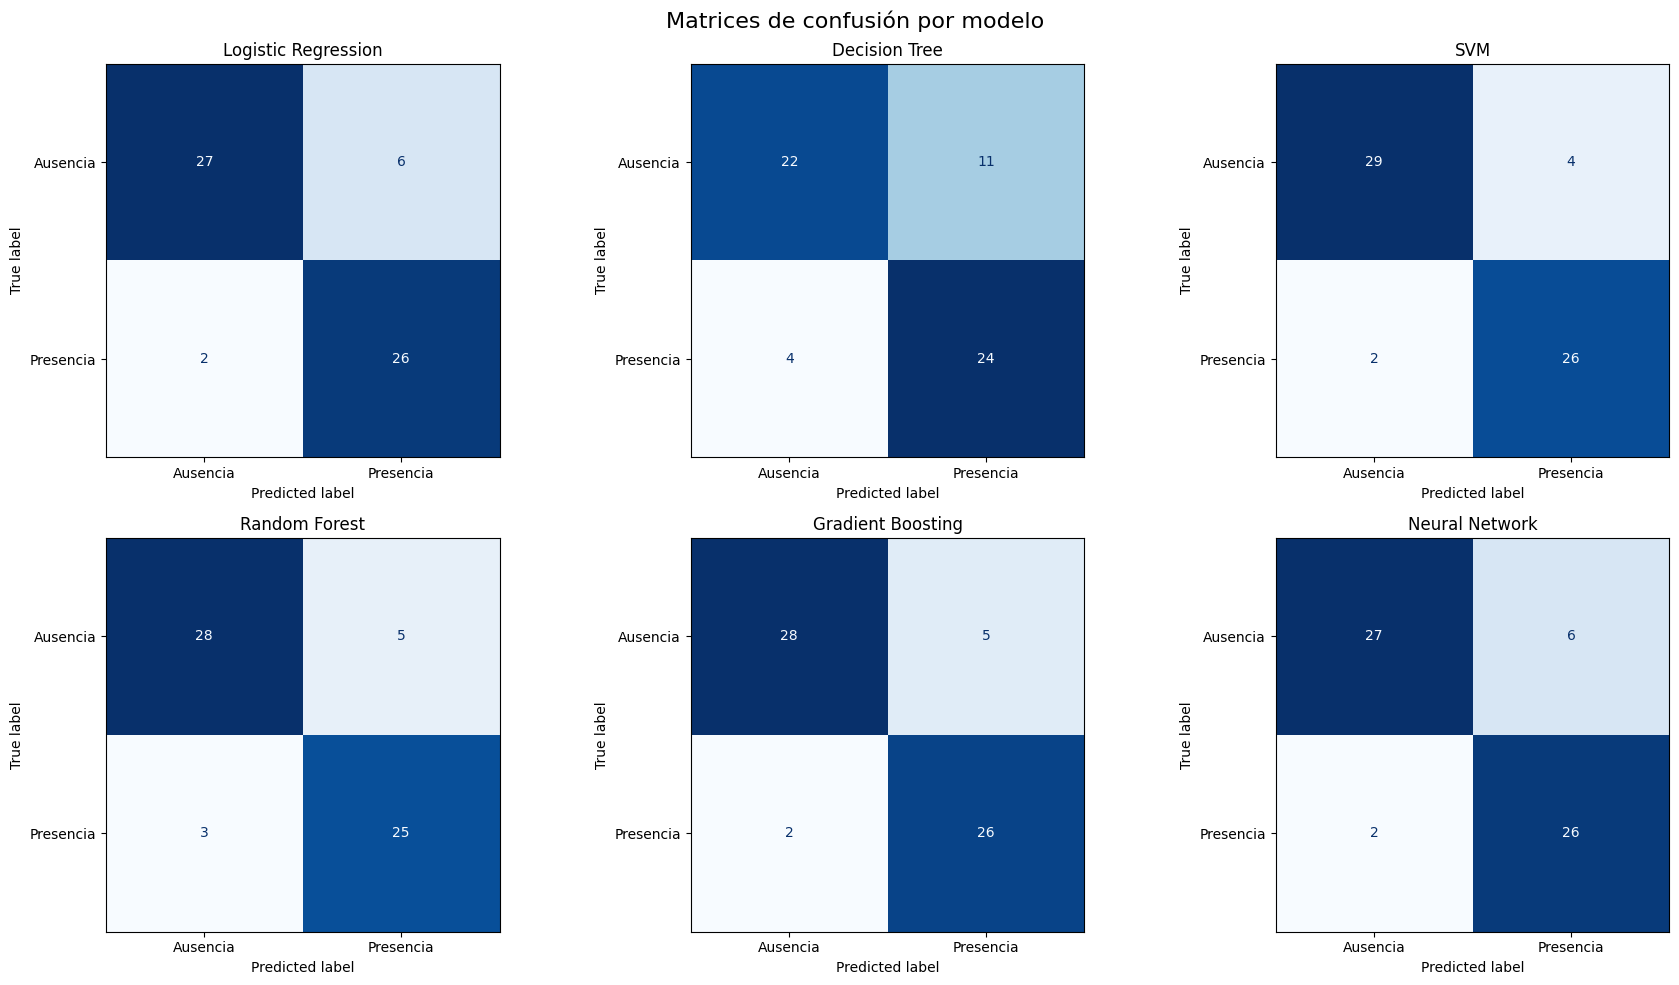

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for axis, (model_name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    matrix = confusion_matrix(y_test, y_pred)
    display = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=["Ausencia", "Presencia"],
    )
    display.plot(ax=axis, cmap="Blues", colorbar=False)
    axis.set_title(model_name)

plt.suptitle("Matrices de confusión por modelo", fontsize=16)
plt.tight_layout()
plt.show()

## 8. Curvas ROC

La curva ROC compara sensibilidad y tasa de falsos positivos en diferentes umbrales. Un modelo con curva más cercana a la esquina superior izquierda tiene mejor discriminación.

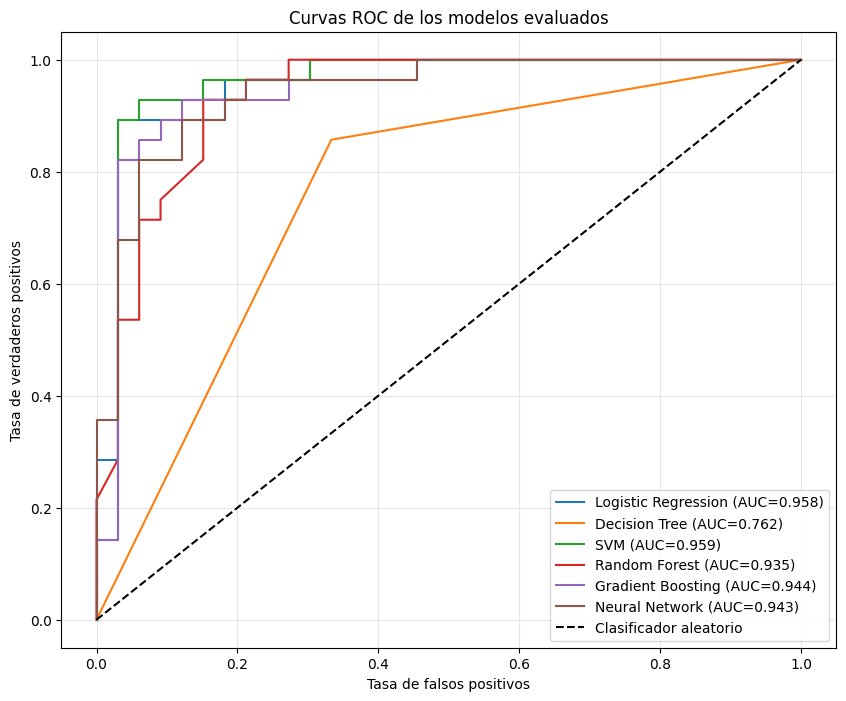

In [10]:
plt.figure(figsize=(10, 8))

for model_name, model in trained_models.items():
    y_score = obtener_puntajes_positivos(model, X_test)
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, y_score)
    auc_value = roc_auc_score(y_test, y_score)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{model_name} (AUC={auc_value:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Clasificador aleatorio")
plt.title("Curvas ROC de los modelos evaluados")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

## 9. Selección automática del mejor modelo

El criterio principal es el mayor ROC-AUC en el conjunto de prueba.

In [11]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_model_auc = results_df.iloc[0]["ROC-AUC"]

print("Mejor modelo:", best_model_name)
print(f"ROC-AUC en test: {best_model_auc:.3f}")

Mejor modelo: SVM
ROC-AUC en test: 0.959


## 10. Conclusiones automáticas del entrenamiento

In [12]:
def generar_conclusiones_modelado(results_dataframe: pd.DataFrame, cv_dataframe: pd.DataFrame) -> list[str]:
    """Genera conclusiones automáticas para el análisis comparativo de modelos.

    Parámetros
    ----------
    results_dataframe : pd.DataFrame
        Resultados de evaluación en el conjunto de prueba.
    cv_dataframe : pd.DataFrame
        Resultados de validación cruzada estratificada.

    Retorna
    -------
    list[str]
        Conclusiones listas para documentar en el artículo científico.
    """
    interpretable_models = ["Logistic Regression", "Decision Tree"]
    complex_models = ["SVM", "Random Forest", "Gradient Boosting", "Neural Network"]

    best_row = results_dataframe.iloc[0]
    neural_network_auc = float(
        results_dataframe.loc[results_dataframe["Model"] == "Neural Network", "ROC-AUC"].iloc[0]
    )
    best_traditional_auc = float(
        results_dataframe.loc[results_dataframe["Model"] != "Neural Network", "ROC-AUC"].max()
    )
    best_interpretable = results_dataframe[results_dataframe["Model"].isin(interpretable_models)].iloc[0]
    best_complex = results_dataframe[results_dataframe["Model"].isin(complex_models)].iloc[0]
    best_cv = cv_dataframe.iloc[0]

    deep_learning_message = (
        "La red neuronal superó a los modelos tradicionales en ROC-AUC de test."
        if neural_network_auc > best_traditional_auc
        else "La red neuronal no superó al mejor modelo tradicional en ROC-AUC de test."
    )

    return [
        f"El mejor modelo en test fue {best_row['Model']} con ROC-AUC={best_row['ROC-AUC']:.3f}.",
        f"Entre los modelos interpretables, destacó {best_interpretable['Model']} con ROC-AUC={best_interpretable['ROC-AUC']:.3f}.",
        f"Entre los modelos más complejos, destacó {best_complex['Model']} con ROC-AUC={best_complex['ROC-AUC']:.3f}.",
        deep_learning_message,
        f"En validación cruzada, el mayor ROC-AUC promedio fue de {best_cv['Model']} ({best_cv['ROC-AUC Mean']:.3f} ± {best_cv['ROC-AUC Std']:.3f}).",
        f"El modelo candidato para explicabilidad con SHAP es {best_row['Model']}, por ser el mejor según ROC-AUC en test.",
    ]


for index, conclusion in enumerate(generar_conclusiones_modelado(results_df, cv_results_df), start=1):
    print(f"{index}. {conclusion}")

1. El mejor modelo en test fue SVM con ROC-AUC=0.959.
2. Entre los modelos interpretables, destacó Logistic Regression con ROC-AUC=0.958.
3. Entre los modelos más complejos, destacó SVM con ROC-AUC=0.959.
4. La red neuronal no superó al mejor modelo tradicional en ROC-AUC de test.
5. En validación cruzada, el mayor ROC-AUC promedio fue de Logistic Regression (0.915 ± 0.021).
6. El modelo candidato para explicabilidad con SHAP es SVM, por ser el mejor según ROC-AUC en test.


## 11. Guardado opcional de resultados y mejor modelo

In [13]:
results_df.to_csv("model_results.csv", index=False)
cv_results_df.to_csv("cv_results.csv", index=False)
joblib.dump(best_model, "best_heart_disease_model.pkl")

print("Archivos guardados:")
print("- model_results.csv")
print("- cv_results.csv")
print("- best_heart_disease_model.pkl")

Archivos guardados:
- model_results.csv
- cv_results.csv
- best_heart_disease_model.pkl
